<a href="https://colab.research.google.com/github/Ammar-Algaithy/retail-customer-segmentation-analysis/blob/main/Retail_Sales_Intelligence_Dashboard_%26_Customer_Segmentation_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛒 Retail Sales Intelligence & Customer Segmentation Engine
## Olist Brazilian E-Commerce Platform | RFM Analysis & K-Means Clustering

---

## 👤 About This Project

This project was built as a demonstration of applied machine learning
and business intelligence on a real world e-commerce dataset.

It uses two techniques studied in a machine learning course —
regression-based statistical analysis and K-means clustering —
and applies them to a real business problem with real financial stakes.

The goal was not just to build a model.
The goal was to answer a question every retail business asks:

> Who are my customers, what are they worth,
> and what should I do about each of them?

---

## 📦 The Dataset

Source:         Olist Brazilian E-Commerce Public Dataset
Platform:       Kaggle — freely available public dataset
Transactions:   100,756 real delivered orders
Customers:      93,357 unique customers
Time Period:    2016 to 2018
Tables Used:    Orders, Customers, Payments, Products, Sellers, Reviews

Olist is a Brazilian e-commerce platform that connects small and medium
sized businesses to customers across multiple online marketplaces.
The dataset is real commercial transaction data, fully anonymized.

---

## 🔬 Techniques Used

RFM Analysis
A proven customer segmentation framework used across retail, banking,
and e-commerce worldwide. Evaluates every customer on three dimensions:
Recency — how recently they bought, Frequency — how often they buy,
and Monetary — how much they spend.

K-Means Clustering
An unsupervised machine learning algorithm that automatically groups
customers based on behavioral similarity. The optimal number of clusters
was determined using the Elbow Method.

Data Preparation
Log transformation to handle extreme outliers and StandardScaler
to normalize all features before clustering — standard practice
in any professional machine learning pipeline.

---

## 📊 What This Notebook Contains

Step 1  — Data Loading
Step 2  — Data Cleaning and Preparation
Step 3  — RFM Analysis and Summary Statistics
Step 4  — Feature Engineering for K-Means
Step 5  — Elbow Method — Finding Optimal Clusters
Step 6  — K-Means Clustering and Segment Identification
Step 7  — Revenue Impact Analysis
Step 8  — Business Recommendations Dashboard
Step 9  — Final Export — Client Ready CSV Deliverable
Step 10 — Project Summary and Strategic Conclusions

---

## 💡 The Core Insight

97% of customers bought exactly once and never returned.
61.7% of all revenue came from customers who are now completely inactive.
Only 3% of customers showed true loyalty and repeat purchase behavior.

Olist does not have an acquisition problem.
Olist has a retention problem.

And the data now tells us exactly what to do about it.

---

## 🛠️ Tools and Libraries

Python 3 | Pandas | NumPy | Scikit-learn | Matplotlib | Google Colab

---

## 📁 Deliverable

olist_customer_segments.csv
93,357 customers fully labeled with segment, priority, and recommended action.
Ready to plug into any CRM or marketing platform and act on immediately.

In [ ]:
# ============================================================
# LOAD ALL DATASETS — RUN THIS FIRST EVERY TIME YOU OPEN COLAB
# ============================================================
import pandas as pd
import numpy as np

orders               = pd.read_csv('/data/olist_orders_dataset.csv')
order_items          = pd.read_csv('/data/olist_order_items_dataset.csv')
customers            = pd.read_csv('/data/olist_customers_dataset.csv')
payments             = pd.read_csv('/data/olist_order_payments_dataset.csv')
products             = pd.read_csv('/data/olist_products_dataset.csv')
reviews              = pd.read_csv('/data/olist_order_reviews_dataset.csv')
sellers              = pd.read_csv('/data/olist_sellers_dataset.csv')
category_translation = pd.read_csv('/data/product_category_name_translation.csv')

print("✅ Orders:",               orders.shape)
print("✅ Order Items:",          order_items.shape)
print("✅ Customers:",            customers.shape)
print("✅ Payments:",             payments.shape)
print("✅ Products:",             products.shape)
print("✅ Reviews:",              reviews.shape)
print("✅ Sellers:",              sellers.shape)
print("✅ Categories:",           category_translation.shape)
print("\n🚀 All datasets loaded and ready")

✅ Orders: (99441, 8)
✅ Order Items: (112650, 7)
✅ Customers: (99441, 5)
✅ Payments: (103886, 5)
✅ Products: (32951, 9)
✅ Reviews: (99224, 7)
✅ Sellers: (3095, 4)
✅ Categories: (71, 2)

🚀 All datasets loaded and ready


In [ ]:
# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================
import pandas as pd   # pandas: used to load, clean, and manipulate data tables
import numpy as np    # numpy: used for numerical and mathematical operations

# ============================================================
# STEP 2: MERGE THE THREE DATASETS INTO ONE TABLE
# ============================================================
# The Olist data is split across multiple CSV files linked by shared ID columns.
# We join them like a database JOIN or Excel VLOOKUP:
#   - orders + customers: linked by 'customer_id'
#   - result + payments:  linked by 'order_id'
df = orders.merge(customers, on='customer_id') \
           .merge(payments, on='order_id')

# ============================================================
# STEP 3: CLEAN THE DATA
# ============================================================
# Keep only orders that were actually delivered (ignore cancelled, processing, etc.)
df = df[df['order_status'] == 'delivered']

# Convert purchase date from plain text to a real Python datetime object
# This allows us to do date math (e.g. how many days ago was this purchase?)
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Remove any rows missing critical fields — we cannot calculate RFM without these
df = df.dropna(subset=['customer_unique_id', 'order_purchase_timestamp', 'payment_value'])

print(f"✅ Clean dataset: {df.shape[0]} delivered orders")

# ============================================================
# STEP 4: SET THE REFERENCE DATE
# ============================================================
# Recency is measured as "days since last purchase relative to today"
# Since this is historical data, we use the day AFTER the last recorded order
# as our reference point so no customer has a recency of 0
reference_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# ============================================================
# STEP 5: BUILD THE RFM TABLE
# ============================================================
# Group all transactions by customer and calculate 3 metrics per customer:
#   Recency   = how many days since their last order (lower = more recent = better)
#   Frequency = how many unique orders they placed (higher = more loyal)
#   Monetary  = total amount they spent across all orders (higher = more valuable)
rfm = df.groupby('customer_unique_id').agg(
    Recency   = ('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    Frequency = ('order_id', 'nunique'),
    Monetary  = ('payment_value', 'sum')
).reset_index()  # reset_index() makes customer_unique_id a regular column again

# ============================================================
# STEP 6: PREVIEW AND SUMMARIZE THE RFM TABLE
# ============================================================
print("\n📊 RFM Table Sample (first 10 customers):")
print(rfm.head(10))  # Show first 10 rows

print(f"\n📐 RFM Shape: {rfm.shape}")  # (rows, columns)

print(f"\n📈 RFM Summary Statistics:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))  # Statistical summary

✅ Clean dataset: 100756 delivered orders

📊 RFM Table Sample (first 10 customers):
                 customer_unique_id  Recency  Frequency  Monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19
2  0000f46a3911fa3c0805444483337064      537          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89
5  0004bd2a26a76fe21f786e4fbd80607f      146          1    166.98
6  00050ab1314c0e55a6ca13cf7181fecf      132          1     35.38
7  00053a61a98854899e70ed204dd4bafe      183          1    419.18
8  0005e1862207bf6ccc02e4228effd9a0      543          1    150.12
9  0005ef4cd20d2893f0d9fbd94d3c0d97      170          1    129.76

📐 RFM Shape: (93357, 4)

📈 RFM Summary Statistics:
        Recency  Frequency  Monetary
count  93357.00   93357.00  93357.00
mean     237.94       1.03    165.20
std      152.58       0.21  

## 📊 Output Analysis: What the RFM Table is Telling Us

### 🔢 Dataset Size
We started with 100,756 delivered orders but ended up with 93,357 unique customers.
The difference means some customers placed more than one order — our most loyal segment.

---

### 👥 Reading the RFM Sample
Nearly every customer in the first 10 rows has a Frequency of 1 — ordered once and never returned.
The summary statistics confirm this is true across all 93,357 customers.

---

## 📊 Summary Statistics Breakdown

The describe() function automatically calculates 8 statistical measures for each column.
Here is what every number means in plain business language.

---

#### 📌 COUNT — 93,357 (same for all three columns)
Count tells us how many customers have a value in that column.
All three columns show 93,357 meaning no customer is missing any data.
Our dataset is complete and ready for modeling.

---

#### 📌 MEAN — Recency: 237 days | Frequency: 1.03 orders | Monetary: 165 USD
Mean is the simple average across all 93,357 customers.
- The average customer last purchased 237 days ago — almost 8 months of silence
- The average customer ordered 1.03 times — essentially once and never again
- The average customer spent 165 USD total across their entire relationship with Olist

---

#### 📌 STD (Standard Deviation) — Recency: 152 | Frequency: 0.21 | Monetary: 226
Standard deviation measures how spread out the numbers are from the average.
- Recency std of 152 means customers vary widely — some bought last week, others 2 years ago
- Frequency std of 0.21 is extremely low — almost everyone ordered exactly once
- Monetary std of 226 is higher than the mean of 165 — a small group of big spenders is pulling the average up. Most customers actually spent much less than 165 USD

---

#### 📌 MIN — Recency: 1 day | Frequency: 1 order | Monetary: 9.59 USD
The lowest value recorded across all 93,357 customers.
- One customer bought just 1 day before our reference date — the freshest customer in the dataset
- Every customer ordered at least once — if they never ordered they would not exist in the data
- The cheapest total spend was 9.59 USD — likely a single low cost item, never returned

---

#### 📌 25% First Quartile — Recency: 114 days | Frequency: 1 | Monetary: 63 USD
This means 25% of all customers fall below these values.
- 25% of customers bought within the last 114 days — your more recent buyers
- 25% of customers spent less than 63 USD total — your low value segment
- Frequency stays at 1 here — at least 25% of customers ordered exactly once

---

#### 📌 50% Median — Recency: 219 days | Frequency: 1 | Monetary: 107 USD
The middle value — 50% of customers are above this and 50% are below.
- Half of all customers last bought more than 219 days ago
- Median frequency is still 1 — confirming the majority ordered only once
- Half of customers spent less than 107 USD — the true middle ground customer

---

#### 📌 75% Third Quartile — Recency: 346 days | Frequency: 1 | Monetary: 182 USD
75% of customers fall below these values — only the top 25% exceed them.
- 75% of customers last bought more than 346 days ago — nearly a year of inactivity
- Frequency is still 1 at the 75th percentile — meaning at least 75% of all customers ordered exactly once
- 75% of customers spent less than 182 USD total

---

#### 📌 MAX — Recency: 695 days | Frequency: 15 orders | Monetary: 13,664 USD
The highest value recorded across all 93,357 customers.
- One customer has not bought in 695 days — almost 2 full years. Completely lost
- One customer ordered 15 times — an exceptionally loyal power user
- One customer spent 13,664 USD — a VIP whale who spent 83x the average customer

---

### 💡 Core Business Insight

Olist has a serious customer retention problem. The data shows that the vast majority
of customers buy once, spend around 165 USD, and never return. The next step is to
dig deeper into these customer behaviors and identify actionable segments.

## 🔧 Next Step: Preparing Data for K-means

### Why we cannot run K-means directly on the raw RFM numbers

Before running the clustering algorithm we must fix some problems identified
in our summary statistics. Skipping this step would produce meaningless clusters.

---

### Fix 1 — Log Transform

Raw Monetary values range from 9 USD to 13,664 USD.
That one whale customer would force the algorithm to build an entire cluster
just for them and lump all other 93,356 customers together.

We will apply np.log1p() which means log(1 + value) to every column.
This compresses extreme values without removing any customers from the data.

---

### Fix 2 — StandardScaler

Even after log transform, Recency and Monetary are still measured in
completely different units — days vs dollars.

StandardScaler will rescale every column so that:
- Mean becomes 0
- Standard deviation becomes 1

After scaling, Recency days and Monetary dollars will carry equal weight.
Neither dimension can overpower the other in the algorithm.

In [ ]:
# ============================================================
# PREPARE DATA FOR K-MEANS CLUSTERING
# ============================================================

import numpy as np
from sklearn.preprocessing import StandardScaler

# ── 4A. LOG TRANSFORM ────────────────────────────────────────
# Problem: Extreme values like 13,664 USD will dominate the algorithm
# Solution: Apply log transform to compress extreme values
# We use log1p which means log(1 + x) — this safely handles any value including small ones

rfm['Recency_log']   = np.log1p(rfm['Recency'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log']  = np.log1p(rfm['Monetary'])

print("✅ Log Transform applied")
print(rfm[['Recency','Recency_log','Frequency','Frequency_log','Monetary','Monetary_log']].head(10))

# ── 4B. STANDARDSCALER ───────────────────────────────────────
# Problem: Recency (days) and Monetary (dollars) are on completely different scales
# Solution: StandardScaler rescales every column to have mean=0 and std=1
# After scaling, all three columns are equally weighted in the algorithm

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[['Recency_log', 'Frequency_log', 'Monetary_log']])

print("\n✅ StandardScaler applied")
print(f"Scaled data shape: {rfm_scaled.shape}")
print(f"\nFirst 5 rows after scaling:")
print(rfm_scaled[:5].round(4))

# Find the customer with the highest spend
print("\n✅ Whale data")
whale = rfm[rfm['Monetary'] == rfm['Monetary'].max()]
print(whale[['Recency', 'Frequency', 'Monetary',
             'Recency_log', 'Frequency_log', 'Monetary_log']])

✅ Log Transform applied
   Recency  Recency_log  Frequency  Frequency_log  Monetary  Monetary_log
0      112     4.727388          1       0.693147    141.90      4.962145
1      115     4.753590          1       0.693147     27.19      3.338967
2      537     6.287859          1       0.693147     86.22      4.468434
3      321     5.774552          1       0.693147     43.62      3.798182
4      288     5.666427          1       0.693147    196.89      5.287711
5      146     4.990433          1       0.693147    166.98      5.123845
6      132     4.890349          1       0.693147     35.38      3.594019
7      183     5.214936          1       0.693147    419.18      6.040683
8      543     6.298949          1       0.693147    150.12      5.018074
9      170     5.141664          1       0.693147    129.76      4.873364

✅ StandardScaler applied
Scaled data shape: (93357, 3)

First 5 rows after scaling:
[[-0.4704 -0.1702  0.2882]
 [-0.4423 -0.1702 -1.7198]
 [ 1.2021 -0.1702 -0.32

## 📊 Output: What Changed

### Log Transform Results

Before and after example from our data:
- Recency 112 days → becomes 4.73 after log transform
- Monetary 141 USD → becomes 4.96 after log transform
- Monetary 13,664 USD → becomes roughly 9.5 after log transform

The massive gap between 141 and 13,664 got compressed into a small gap
between 4.96 and 9.5. The whale customer is still in the data —
we just brought them close enough to everyone else so they do not
dominate the algorithm.

Notice that Frequency_log shows 0.693 for every customer in the sample.
That is because all these customers ordered exactly once and log(1+1) always equals 0.693.
This confirms what we found earlier — most customers are identical on the Frequency dimension.

---

### StandardScaler Results

The scaled values like -0.4704 and 1.2021 look strange but have a simple meaning:

| Scaled Value | What it means |
|---|---|
| 0 | Exactly average |
| Positive number | Above average |
| Negative number | Below average |
| Far from 0 | Very different from average |

Reading the first customer: [-0.4704, -0.1702, 0.2882]
- Recency: -0.47 — slightly more recent than average — good
- Frequency: -0.17 — very close to average frequency — neutral
- Monetary: +0.29 — slightly higher spend than average — good

---

### What happens next

Every one of our 93,357 customers is now represented by just 3 clean numbers
on a uniform scale. The data is ready for K-means clustering.

## 📐 Next Step: Finding the Right Number of Clusters — The Elbow Method

### What is this step trying to answer?

Before running K-means we have to answer one critical question:
How many customer segments should we create?

Should we split our 93,357 customers into 2 groups? 3 groups? 10 groups?
There is no obvious answer — and if we guess wrong the segments will be
either too broad to be useful or too narrow to be actionable.

The Elbow Method is the standard technique data scientists use to find the answer.

---

### How does it work?

We run K-means multiple times — once for k=1, once for k=2, all the way up to k=10.
Each time we record a score called Inertia.

Inertia measures how tightly packed each cluster is.
In simple terms — how similar are the customers within each group?

- Low inertia = customers within each cluster are very similar to each other = good
- High inertia = customers within each cluster are very different from each other = bad

---

### Why does inertia always go down as k increases?

This is important to understand.

If you have 93,357 customers and you create 93,357 clusters — one per customer —
inertia would be zero because every customer is perfectly grouped alone.
But that is completely useless for business.

If you create just 1 cluster — everyone is in the same group —
inertia would be enormous because customers are very different from each other.
That is also useless.

The sweet spot is somewhere in between.

---

### What is the Elbow?

When we plot inertia against number of clusters we get a curve that drops sharply
at first and then flattens out. The point where it stops dropping sharply and
starts flattening is called the Elbow.

That elbow point is our answer — it is the number of clusters where we get
the best balance between simplicity and accuracy.

Adding more clusters beyond the elbow gives us very little improvement
but makes the business segments harder to explain and act on.

---

### Why does this matter for the business?

From a business perspective, the number of segments determines how many
different customer strategies Olist needs to create.

2 segments = too simple, misses important differences between customers
10 segments = too complex, impossible to create 10 different marketing strategies
4 or 5 segments = actionable, clear, and explainable to any executive

The Elbow Method gives us the data to justify our choice.

k=1 → inertia: 280071.00
k=2 → inertia: 190212.02
k=3 → inertia: 129160.67
k=4 → inertia: 82895.74
k=5 → inertia: 68319.64
k=6 → inertia: 58425.99
k=7 → inertia: 51222.41
k=8 → inertia: 45832.37
k=9 → inertia: 41066.43
k=10 → inertia: 36693.87


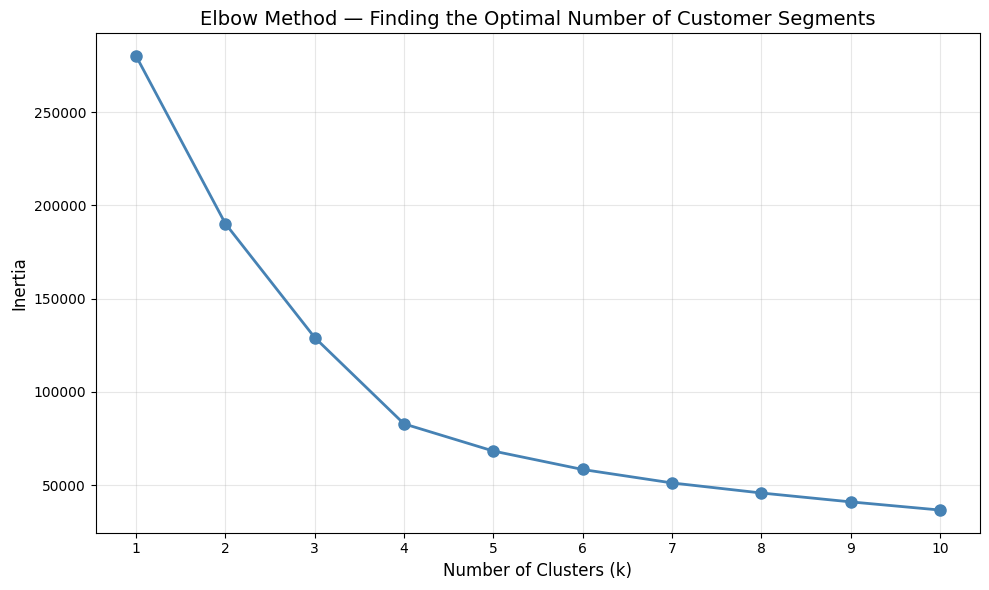


✅ Look for the elbow — the point where the curve stops dropping sharply


In [ ]:
# ============================================================
# FIND THE RIGHT NUMBER OF CLUSTERS — ELBOW METHOD
# ============================================================

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# We test k-means with different numbers of clusters from 1 to 10
# For each number we record the inertia — which measures how tight the clusters are
# Lower inertia = customers within each cluster are closer together = better clusters

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    print(f"k={k} → inertia: {kmeans.inertia_:.2f}")

# ── PLOT THE ELBOW CURVE ─────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.title('Elbow Method — Finding the Optimal Number of Customer Segments', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Look for the elbow — the point where the curve stops dropping sharply")

## 📊 Output: Reading the Elbow Curve

### What the Inertia Numbers Tell Us

Each time we add a new cluster, inertia drops — but by how much?
That is the key question. Here is what happened in our data:

| Clusters | Inertia | Drop from previous | Signal |
|---|---|---|---|
| k=1 | 280,071 | — | Starting point — everyone in one group |
| k=2 | 190,212 | 89,859 drop | Massive improvement |
| k=3 | 129,161 | 61,051 drop | Still massive improvement |
| k=4 | 82,896 | 46,265 drop | Still significant improvement |
| k=5 | 68,320 | 14,576 drop | Drop is shrinking fast |
| k=6 | 58,426 | 9,894 drop | Getting smaller |
| k=7 | 51,222 | 7,204 drop | Small improvement |
| k=8 | 45,832 | 5,390 drop | Small improvement |
| k=9 | 41,066 | 4,766 drop | Barely improving |
| k=10 | 36,694 | 4,372 drop | Almost no improvement |

The drops from k=1 to k=4 are enormous — each new cluster is finding
genuinely different customer groups and adding real value.

From k=5 onwards the drops get much smaller — we are getting diminishing returns.
Adding more clusters beyond this point gives us very little improvement
but makes the business segments harder to explain and act on.

---

### The Verdict — Our Elbow is at k=4

4 customer segments is the optimal choice for this dataset.
This means we will sort all 93,357 customers into exactly 4 groups.
Each group will represent a meaningfully different type of customer
with their own behavior pattern and business strategy.

---

### What the Chart is Showing You

The chart shows a curve with:
- X axis — number of clusters tested from 1 through 10
- Y axis — inertia score for each number of clusters
- Each blue dot — one K-means test result
- The line connecting dots — how fast inertia is dropping

The curve starts very high on the left at k=1 with inertia of 280,071.
This makes sense — when everyone is in one group customers are very different from each other.

The curve drops steeply through k=2, k=3, and k=4.
Each new cluster is capturing a genuinely distinct group of customers.

At k=4 the curve visibly bends and starts to flatten out.
This bend is the elbow — the point of maximum value.

From k=5 onwards the curve becomes almost flat.
Adding more clusters stops making a meaningful difference.

---

### Why the Curve Never Reaches Zero

You might wonder — why not just keep adding clusters until inertia hits zero?

Technically you could create 93,357 clusters — one per customer — and inertia would be zero.
But that would be completely useless for business.
You cannot create 93,357 different marketing strategies.

The elbow method finds the sweet spot between mathematical perfection
and real world business practicality.

---

### Our Decision

We will use k=4 — four customer segments.

This gives us:
- Enough detail to find meaningfully different customer types
- Few enough segments to create clear and actionable business strategies
- A mathematically justified choice backed by the elbow curve

Next we run K-means with k=4 and label every one of our 93,357 customers.

## 🎯 Next Step: Running K-means Clustering

### What is this step doing?

Now that we know the optimal number of clusters is 4,
we run K-means one final time with k=4.

The algorithm will read every customer's 3 scaled numbers
— Recency, Frequency, and Monetary —
and automatically sort all 93,357 customers into 4 groups.

Customers who behave similarly will end up in the same group.
Customers who behave differently will end up in different groups.

---

### How does K-means actually work?

The algorithm follows 4 simple steps:

Step 1 — Place 4 random center points in the data
Step 2 — Assign every customer to their nearest center point
Step 3 — Recalculate each center point based on the customers assigned to it
Step 4 — Repeat steps 2 and 3 until the groups stop changing

When the groups stop changing the algorithm has converged
and every customer has their final cluster label.

---

### What will we get at the end?

Every one of our 93,357 customers will receive a cluster number — 0, 1, 2, or 3.
We will then look at the average Recency, Frequency, and Monetary of each cluster
to understand who is in each group and give them a business label such as:

🟢 Champions — bought recently, buy often, spend the most
🔵 Loyal Customers — buy regularly and spend well
🟡 At Risk Customers — used to buy but have gone quiet
🔴 Lost Customers — bought once long ago and never returned

✅ K-means clustering complete

Cluster distribution — how many customers in each group:
Cluster
0    32185
1    42287
2     2801
3    16084
Name: count, dtype: int64

📊 Cluster Summary — Average behavior per group:
         Recency_mean  Frequency_mean  Monetary_mean  Customer_count
Cluster                                                             
0              272.48            1.00         295.78           32185
1              287.33            1.00          68.21           42287
2              220.29            2.11         308.59            2801
3               42.02            1.00         133.91           16084


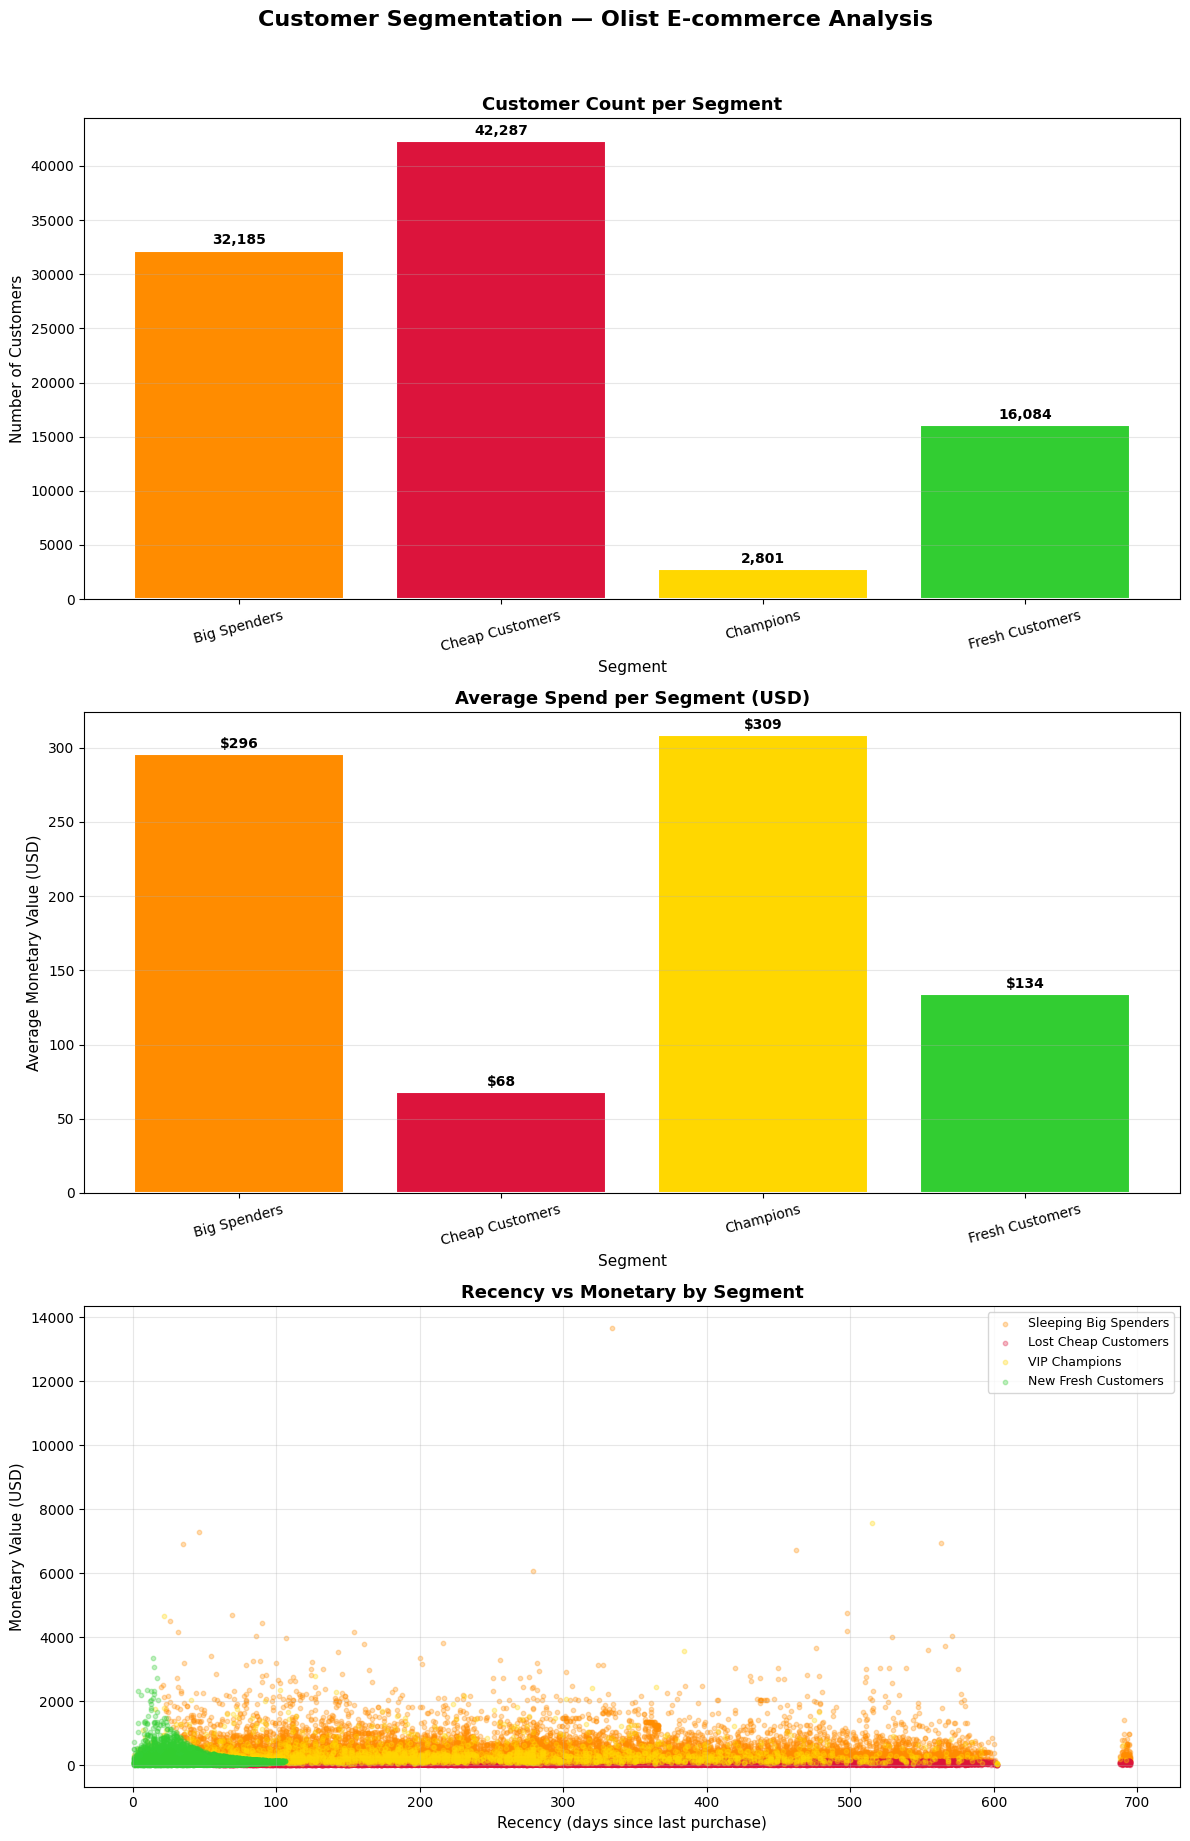

✅ Visualizations complete


In [ ]:
# ============================================================
# STEP 6: RUN K-MEANS WITH k=4 AND VISUALIZE RESULTS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans

# ── RUN K-MEANS ──────────────────────────────────────────────
# random_state=42 ensures we get the same result every time we run it
# n_init=10 means the algorithm tries 10 different starting points and picks the best
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(rfm_scaled)

# Assign cluster label to every customer in our RFM table
rfm['Cluster'] = kmeans.labels_

print("✅ K-means clustering complete")
print(f"\nCluster distribution — how many customers in each group:")
print(rfm['Cluster'].value_counts().sort_index())

# ── CALCULATE AVERAGE RFM PER CLUSTER ────────────────────────
# This tells us the average behavior of customers in each cluster
cluster_summary = rfm.groupby('Cluster').agg(
    Recency_mean   = ('Recency',   'mean'),
    Frequency_mean = ('Frequency', 'mean'),
    Monetary_mean  = ('Monetary',  'mean'),
    Customer_count = ('customer_unique_id', 'count')
).round(2)

print("\n📊 Cluster Summary — Average behavior per group:")
print(cluster_summary)

# ── CLUSTER LABELS AND COLORS ─────────────────────────────────
cluster_labels = {
    0: 'Sleeping Big Spenders',
    1: 'Lost Cheap Customers',
    2: 'VIP Champions',
    3: 'New Fresh Customers'
}

colors = {
    0: '#FF8C00',  # orange
    1: '#DC143C',  # red
    2: '#FFD700',  # gold
    3: '#32CD32'   # green
}

rfm['Cluster_Label'] = rfm['Cluster'].map(cluster_labels)

# ── FIGURE WITH 3 CHARTS ──────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
fig.suptitle('Customer Segmentation — Olist E-commerce Analysis',
             fontsize=16, fontweight='bold', y=1.02)

# ── CHART 1: CUSTOMER COUNT PER SEGMENT ──────────────────────
cluster_counts = rfm['Cluster'].value_counts().sort_index()
bar_colors = [colors[i] for i in cluster_counts.index]
bars = axes[0].bar(
    [cluster_labels[i].split(' ', 1)[1] for i in cluster_counts.index],
    cluster_counts.values,
    color=bar_colors,
    edgecolor='white',
    linewidth=1.5
)
axes[0].set_title('Customer Count per Segment', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers', fontsize=11)
axes[0].set_xlabel('Segment', fontsize=11)
for bar, val in zip(bars, cluster_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)

# ── CHART 2: AVERAGE MONETARY PER SEGMENT ────────────────────
monetary_means = rfm.groupby('Cluster')['Monetary'].mean().sort_index()
bar_colors2 = [colors[i] for i in monetary_means.index]
bars2 = axes[1].bar(
    [cluster_labels[i].split(' ', 1)[1] for i in monetary_means.index],
    monetary_means.values,
    color=bar_colors2,
    edgecolor='white',
    linewidth=1.5
)
axes[1].set_title('Average Spend per Segment (USD)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Monetary Value (USD)', fontsize=11)
axes[1].set_xlabel('Segment', fontsize=11)
for bar, val in zip(bars2, monetary_means.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'${val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)

# ── CHART 3: RECENCY VS MONETARY SCATTER PLOT ────────────────
for cluster_id, label in cluster_labels.items():
    mask = rfm['Cluster'] == cluster_id
    axes[2].scatter(
        rfm[mask]['Recency'],
        rfm[mask]['Monetary'],
        c=colors[cluster_id],
        label=label,
        alpha=0.3,
        s=10
    )
axes[2].set_title('Recency vs Monetary by Segment', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Recency (days since last purchase)', fontsize=11)
axes[2].set_ylabel('Monetary Value (USD)', fontsize=11)
axes[2].legend(loc='upper right', fontsize=9)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizations complete")

# 🔍 Initial Findings: Customer Segmentation Overview
## Olist E-Commerce Platform — RFM & K-Means Clustering Report

---

## 📋 Executive Summary

Using RFM analysis and K-means clustering on 93,357 Olist customers,
we identified four distinct customer segments with fundamentally different
behavioral profiles and revenue potential.

The analysis reveals a critical structural challenge: **97% of Olist's customer
base are one-time buyers who never returned.** A small but highly valuable **3%
of customers — the VIP Champions** — showed true repeat purchase behavior.

However as the revenue analysis in Step 7 will reveal, the segment that
truly holds Olist's financial future is not the smallest — it is the one
that spent the most and then went completely silent.

---

## 📊 Chart 1 — Customer Count per Segment

This bar chart shows the size of each customer segment.

The most striking observation is the sheer dominance of the 🔴 Lost Cheap Customers
segment at **45% of the entire customer base.** Combined with 🟠 Sleeping Big Spenders
at 34.5%, this means **nearly 80% of all customers have gone inactive.**

The 🌟 VIP Champions bar is barely visible at 3% — yet as the revenue analysis
in Step 7 will show, this small group carries enormous financial weight
on a per-customer basis.

> 💡 Key Takeaway: Olist is acquiring customers at scale but failing to retain them.
> The funnel is wide at the top and almost completely closed at the bottom.

---

## 💰 Chart 2 — Average Spend per Segment

This bar chart reveals the revenue quality of each segment.

🌟 VIP Champions and 🟠 Sleeping Big Spenders both average above **$295 per customer** —
nearly **4 times more** than the 🔴 Lost Cheap Customers at just $68.

This creates a critical strategic distinction: **not all inactive customers are equal.**
The 🟠 Sleeping Big Spenders went quiet but they proved they have both the intent
and the purchasing power to spend significantly more than the average customer.

Re-engaging a Sleeping Big Spender is worth approximately **4 times more**
than re-engaging a Lost Cheap Customer — before a single marketing dollar is spent.

> 💡 Key Takeaway: Revenue potential is concentrated in segments that represent
> less than 40% of the customer base. Marketing spend must reflect this reality.

---

## 🔍 Chart 3 — Recency vs Monetary Scatter Plot

This scatter plot maps every one of the 93,357 customers across two dimensions:
how recently they bought on the X axis and how much they spent on the Y axis.

Each color represents one segment. Reading the chart:

🟢 The green cluster sits tightly on the left side of the X axis — confirming
that New Fresh Customers bought very recently regardless of spend level.

🔴 🟠 The red and orange clusters overlap heavily in the middle and right —
both groups went inactive around the same time. However the orange
Sleeping Big Spenders sit noticeably higher on the Y axis,
visually confirming their significantly higher spend.

🌟 The gold VIP Champions are scattered across the chart but consistently
appear at the top of the Y axis — the highest spenders at every recency level.

> 💡 Key Takeaway: Recency and Monetary together reveal what neither dimension
> could show alone — who spent the most and how long ago they disappeared.

---

## 🔬 Segment Deep Dive

---

### 🔴 Segment 1 — Lost Cheap Customers
#### 42,287 customers | 45.3% of base | $68 avg spend | 287 days inactive

**Profile:** The largest and least valuable segment. These customers made a
single low-value purchase approximately 10 months ago and never returned.
Their low spend suggests price sensitivity, dissatisfaction, or a purely
opportunistic one-time purchase driven by a promotion or discount.

**Business Implication:** The cost of re-engaging this segment through paid
marketing channels would likely exceed the expected revenue return.
Nearly half the customer base is generating the lowest revenue per head.

**Recommended Action:** Suppress from paid re-engagement campaigns.
If contacted at all, use only zero-cost channels such as email.
Set a strict revenue threshold — if they do not convert above $50,
remove from active marketing lists permanently.

---

### 🟠 Segment 2 — Sleeping Big Spenders
#### 32,185 customers | 34.5% of base | $295 avg spend | 272 days inactive

**Profile:** This segment mirrors Lost Cheap Customers in behavior —
single purchase, now inactive — but with one critical difference.
They spent an average of $295 per transaction, nearly four times more.
This signals higher purchasing power, stronger product-market fit,
and a relationship genuinely worth investing in to reactivate.

**Business Implication:** Even a 10% reactivation rate on this segment
would generate approximately **$950,000 in recovered revenue.**
As Step 7 will confirm, this segment is the financial backbone of Olist —
responsible for 61.7% of all platform revenue despite being inactive.

**Recommended Action:** Launch a targeted win-back campaign with a
personalized offer tied to their original purchase category.
Use urgency-driven messaging — limited time offer, exclusive return discount.
A/B test offer sizes between 10% and 20% to find the optimal conversion rate.

---

### 🟢 Segment 3 — New Fresh Customers
#### 16,084 customers | 17.2% of base | $133 avg spend | 42 days inactive

**Profile:** The most recently acquired customers on the platform.
They made their first purchase approximately 6 weeks ago and have not returned.
They are the **highest-risk and highest-opportunity** segment simultaneously —
still warm but cooling rapidly with every passing week.

**Business Implication:** Without intervention, new customers follow a
predictable path toward the Lost Cheap Customers or Sleeping Big Spenders
segments within 3 to 6 months. The window to change this is narrow.

**Recommended Action:** Trigger an immediate onboarding sequence within
the first 30 days post-purchase. Include product recommendations based
on first purchase category, a second-purchase incentive, and social proof
content to build platform trust. Speed is the critical variable —
every week of inaction increases churn probability significantly.

---

### 🌟 Segment 4 — VIP Champions
#### 2,801 customers | 3.0% of base | $308 avg spend | 2.11 avg orders

**Profile:** Despite representing only 3% of the customer base, VIP Champions
are the only segment that came back to buy more than once.
Their combination of high spend and repeat behavior makes them
**exponentially more valuable** than any other customer on the platform.

**Business Implication:** A single VIP Champion who churns represents
the revenue equivalent of approximately **4.5 Lost Cheap Customers.**
Protecting and growing this segment is a top-line revenue imperative.
The path to transformational revenue growth runs directly through
converting more customers into VIP Champions.

**Recommended Action:** Enroll all VIP Champions in a dedicated loyalty program
with exclusive benefits — early access, free shipping, dedicated support,
and personal outreach. Trigger immediate re-engagement the moment a
VIP Champion goes 60 days without a purchase.

---

## 🎯 Initial Strategic Conclusion

The K-means clustering model has successfully identified four distinct
customer realities within what was previously one undifferentiated base.

The core finding is clear: **Olist does not have an acquisition problem.
It has a retention problem.** 97% of customers never came back.

**Preliminary priority order based on behavioral data alone:**

1. 🌟 **VIP Champions** — Highest per-customer value. Protect and grow.
2. 🟠 **Sleeping Big Spenders** — High spend proven. Worth winning back.
3. 🟢 **New Fresh Customers** — Still warm. Act immediately.
4. 🔴 **Lost Cheap Customers** — Lowest value. Lowest priority.

> ⚠️ Note: This priority order is based on behavioral metrics alone.
> The Revenue Impact Analysis in the next Step will refine these priorities
> significantly when total revenue contribution is taken into account.

# 💵 Revenue Impact Analysis

## What is this step trying to answer?

So far we know how many customers are in each segment and how they behave.
But we have not yet answered the most important business question of all:

> How much money is each segment actually worth?

A segment with 42,287 customers sounds large and important.
But if those customers collectively spent less than a segment of 2,801 customers
then the numbers tell a completely different story about where to focus.

This step calculates the total revenue contribution of each segment,
the average revenue per customer, and the percentage of total platform
revenue that each group represents.

---

## Why does this matter?

In any real business conversation — especially at IBM — decisions are made
based on revenue impact, not just customer counts.

Knowing that VIP Champions are 3% of customers is interesting.
Knowing that VIP Champions generate X% of total revenue is actionable.

That is the difference between a data observation and a business insight.

💰 Revenue Impact by Segment:
                       Segment  Customer_Count  Total_Revenue  Avg_Revenue  \
Cluster                                                                      
0        Sleeping Big Spenders           32185     9519736.26       295.78   
1         Lost Cheap Customers           42287     2884523.47        68.21   
2                VIP Champions            2801      864357.21       308.59   
3          New Fresh Customers           16084     2153844.83       133.91   

         Revenue_Pct  
Cluster               
0              61.73  
1              18.70  
2               5.60  
3              13.97  

💵 Total Platform Revenue: $15,422,461.77


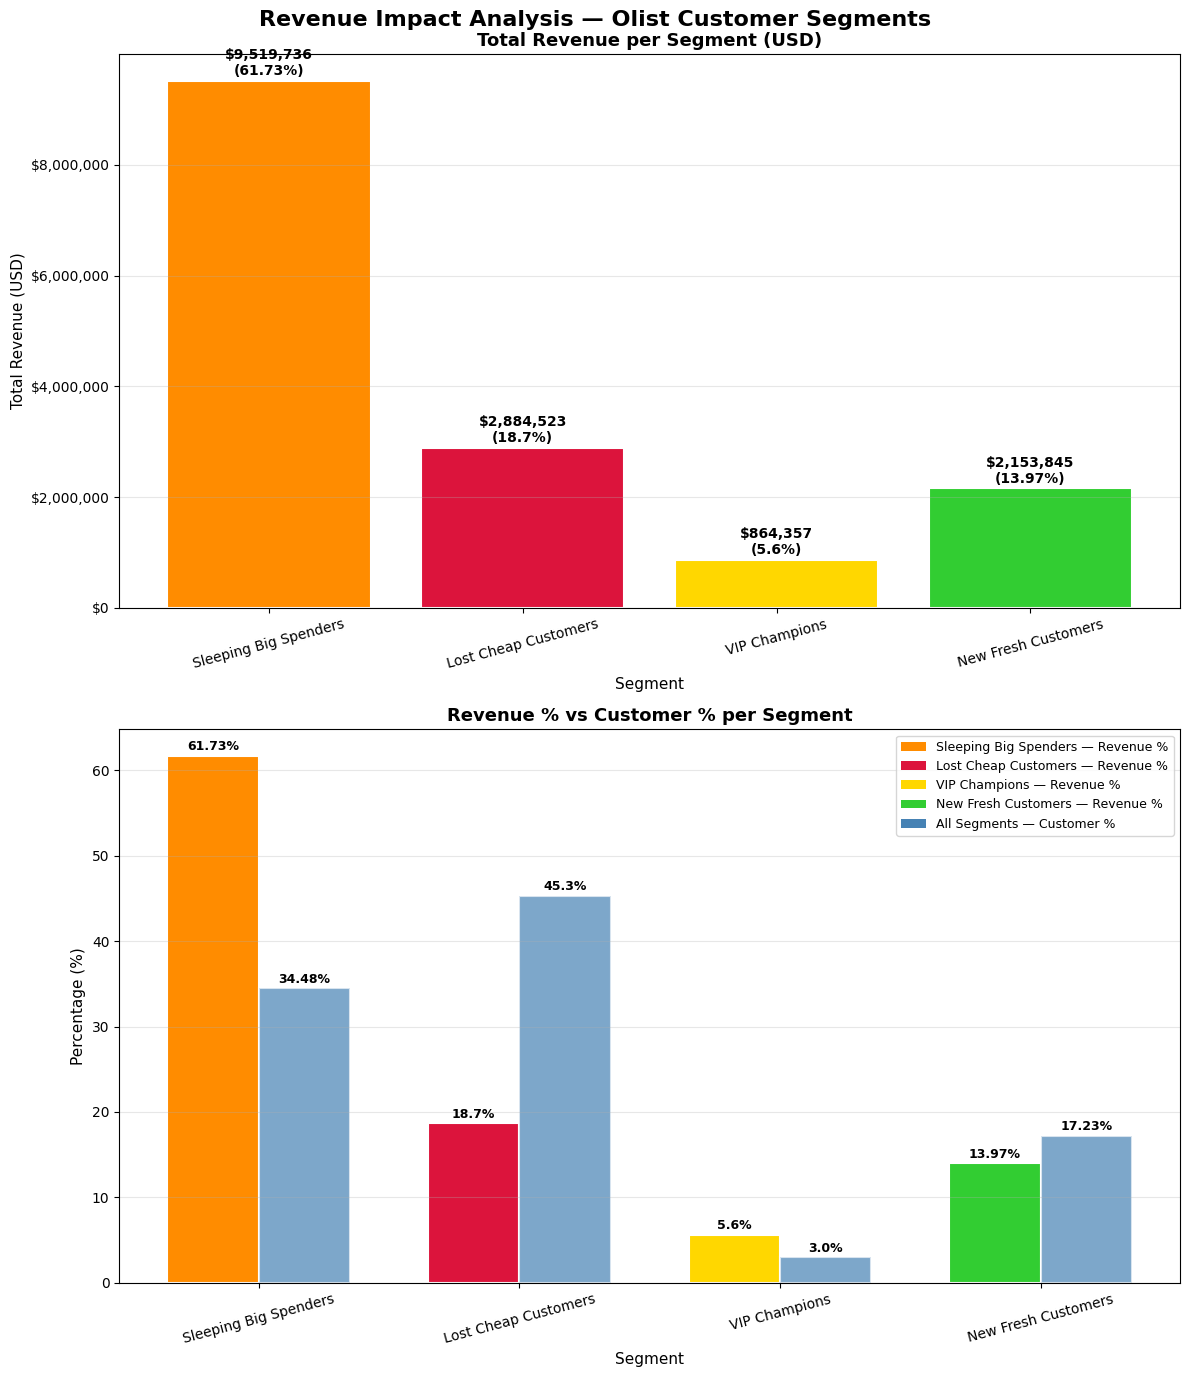

In [ ]:
# ============================================================
# REVENUE IMPACT ANALYSIS
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── CALCULATE TOTAL REVENUE PER SEGMENT ──────────────────────
# Sum up all monetary values per cluster
revenue_summary = rfm.groupby('Cluster').agg(
    Segment          = ('Cluster_Label', 'first'),
    Customer_Count   = ('customer_unique_id', 'count'),
    Total_Revenue    = ('Monetary', 'sum'),
    Avg_Revenue      = ('Monetary', 'mean'),
    Max_Revenue      = ('Monetary', 'max'),
    Min_Revenue      = ('Monetary', 'min')
).round(2)

# Calculate percentage of total revenue per segment
total_revenue = revenue_summary['Total_Revenue'].sum()
revenue_summary['Revenue_Pct'] = (
    (revenue_summary['Total_Revenue'] / total_revenue) * 100
).round(2)

print("💰 Revenue Impact by Segment:")
print(revenue_summary[['Segment','Customer_Count','Total_Revenue','Avg_Revenue','Revenue_Pct']])
print(f"\n💵 Total Platform Revenue: ${total_revenue:,.2f}")

# ── PLOT REVENUE IMPACT ───────────────────────────────────────
segment_names  = revenue_summary['Segment'].values
total_revenues = revenue_summary['Total_Revenue'].values
revenue_pcts   = revenue_summary['Revenue_Pct'].values
customer_counts = revenue_summary['Customer_Count'].values

colors = ['#FF8C00', '#DC143C', '#FFD700', '#32CD32']

fig, axes = plt.subplots(2, 1, figsize=(12, 14))
fig.suptitle('Revenue Impact Analysis — Olist Customer Segments',
             fontsize=16, fontweight='bold')

# ── CHART 1: TOTAL REVENUE PER SEGMENT ───────────────────────
bars = axes[0].bar(segment_names, total_revenues,
                   color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Total Revenue per Segment (USD)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Total Revenue (USD)', fontsize=11)
axes[0].set_xlabel('Segment', fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'${x:,.0f}'))
for bar, val, pct in zip(bars, total_revenues, revenue_pcts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 50000,
                f'${val:,.0f}\n({pct}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)

# ── CHART 2: REVENUE % VS CUSTOMER % COMPARISON ──────────────
x = range(len(segment_names))
width = 0.35

bars1 = axes[1].bar([i - width/2 for i in x],
                    revenue_pcts, width,
                    label='% of Total Revenue',
                    color=colors, edgecolor='white', linewidth=1.5)

bars2 = axes[1].bar([i + width/2 for i in x],
                    customer_pcts, width,
                    label='% of Total Customers',
                    color='steelblue', edgecolor='white', linewidth=1.5,
                    alpha=0.7)

axes[1].set_title('Revenue % vs Customer % per Segment', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].set_xlabel('Segment', fontsize=11)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(segment_names, rotation=15)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF8C00', label='Sleeping Big Spenders — Revenue %'),
    Patch(facecolor='#DC143C', label='Lost Cheap Customers — Revenue %'),
    Patch(facecolor='#FFD700', label='VIP Champions — Revenue %'),
    Patch(facecolor='#32CD32', label='New Fresh Customers — Revenue %'),
    Patch(facecolor='steelblue', label='All Segments — Customer %'),
]
axes[1].legend(handles=legend_elements, fontsize=9, loc='upper right')
axes[1].grid(axis='y', alpha=0.3)

for bar, val in zip(bars1, revenue_pcts):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{val}%', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

for bar, val in zip(bars2, customer_pcts):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{val}%', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# 💵 Step 7 Output: Revenue Impact Analysis

## Total Platform Revenue: $15,422,461.77

Across all 93,357 customers and every transaction in the dataset,
Olist generated a total of $15,422,461.77 in platform revenue.

But the way that revenue is distributed across segments tells a story
that changes everything about how Olist should think about its customers.

---

## 💰 Revenue Distribution — The Full Picture

| Segment | Customers | % of Customers | Total Revenue | % of Revenue | Avg Spend |
|---|---|---|---|---|---|
| 🟠 Sleeping Big Spenders | 32,185 | 34.5% | $9,519,736 | 61.7% | $295 |
| 🔴 Lost Cheap Customers | 42,287 | 45.3% | $2,884,523 | 18.7% | $68 |
| 🟢 New Fresh Customers | 16,084 | 17.2% | $2,153,844 | 14.0% | $133 |
| 🌟 VIP Champions | 2,801 | 3.0% | $864,357 | 5.6% | $308 |

---

## 📊 Chart 1 — Total Revenue per Segment

This chart shows the absolute dollar contribution of each segment
to Olist's total platform revenue.

The orange bar for Sleeping Big Spenders towers above every other segment
at $9,519,736 — representing 61.7 cents of every single dollar
Olist has ever earned on its platform.

The red bar for Lost Cheap Customers is the second largest despite having
the most customers — 42,287 people only generated $2,884,523 combined.
That is the direct financial cost of a low average spend of $68 per customer.

The gold bar for VIP Champions is the smallest despite having the
highest average spend — simply because there are so few of them at only 2,801.
This gap between potential and reality is Olist's single biggest growth opportunity.

> 💡 Key Takeaway: The largest customer segment is not the most valuable one.
> Size and revenue are not the same thing.

---

## 📊 Chart 2 — Revenue % vs Customer % per Segment

This is the most powerful chart in the entire analysis.

It compares two bars side by side for each segment:
- The COLORED bar (orange, red, gold, green) shows % of total REVENUE
- The BLUE bar shows % of total CUSTOMERS

When these two bars are very different in height it reveals
a mismatch between customer size and revenue contribution.

---

### Reading the mismatches:

🟠 Sleeping Big Spenders — Revenue 61.7% (orange) vs Customers 34.5% (blue)
The orange revenue bar is nearly double the blue customer bar.
This segment generates far more revenue than its size would suggest.
It is Olist's most disproportionately valuable segment.

🔴 Lost Cheap Customers — Revenue 18.7% (red) vs Customers 45.3% (blue)
The blue customer bar is more than double the red revenue bar.
Nearly half the customer base is generating less than a fifth of revenue.
This is the clearest sign of a low quality customer acquisition problem.

🟢 New Fresh Customers — Revenue 14.0% (green) vs Customers 17.2% (blue)
The two bars are close in height — this segment is roughly pulling its weight.
But without intervention it will slide toward the Lost Cheap Customers pattern.

🌟 VIP Champions — Revenue 5.6% (gold) vs Customers 3.0% (blue)
The gold revenue bar is slightly higher than the blue customer bar.
VIP Champions do generate more than their size suggests —
but the gap is surprisingly small because there are simply not enough of them.
Growing this segment is the highest leverage move available to Olist.

---

## 🔑 The Two Most Powerful Insights

---

### Insight 1 — The Sleeping Big Spenders are the real revenue engine

61.7% of all platform revenue — $9,519,736 out of $15,422,461 —
came from a single segment that bought once and went completely quiet.

This means Olist's entire business is being held up by customers
who have already left. There is no guarantee they will ever return.
If Olist does not win them back the financial consequences are severe.

A targeted win-back campaign that reactivates just 10% of this segment
would recover approximately $951,973 in revenue — nearly $1 million
from a single focused marketing effort.

---

### Insight 2 — VIP Champions are massively underscaled

VIP Champions have the highest average spend at $308 and are the only
segment that came back to buy more than once. Yet they represent just
3% of the customer base and 5.6% of revenue.

The math of scaling this segment is compelling:

Current state: 2,801 VIP Champions generating $864,357
If grown to 10,000: estimated $3,085,900 in revenue
If grown to 20,000: estimated $6,171,800 in revenue

Growing the VIP Champion segment from 3% to just 10% of the customer base
would add an estimated $5.3 million in annual revenue —
a 34% increase on total platform revenue from one strategic initiative alone.

---

## 🎯 Revenue-Based Strategic Priorities

Based on this revenue analysis the strategic priorities are now clear
and backed by hard numbers:

**Priority 1 — Reactivate Sleeping Big Spenders**
61.7% of all revenue is sitting dormant in this segment.
A 10% reactivation rate = $951,973 recovered.
This is the single highest short term revenue opportunity on the platform.

**Priority 2 — Protect and grow VIP Champions**
Highest revenue per customer at $308 avg spend.
Every new VIP Champion added is the highest long term return available.
Growing this segment from 3% to 10% of the base adds $5.3 million in revenue.

**Priority 3 — Convert New Fresh Customers before they go cold**
14% of revenue and still warm. Act within 30 days or lose them forever
to the Lost Cheap Customers or Sleeping Big Spenders segments.

**Priority 4 — Minimize spend on Lost Cheap Customers**
45% of customers generating only 18.7% of revenue.
Redirect every saved marketing dollar to Priorities 1 through 3.

> ⚠️ Every dollar spent re-engaging a Lost Cheap Customer
> is a dollar not spent growing a VIP Champion.
> The data makes the right choice clear.

# 🎯 Step 8: Business Recommendations Dashboard

## What is this step doing?

Every step so far has been analytical — loading data, cleaning it,
building models, and interpreting results.

This final visualization step translates all of that analysis into
a single actionable dashboard that any business executive can read
and act on immediately — without needing to understand a single line of code.

This is the deliverable. This is what you hand to the client.

---

## Why does this matter?

In a real consulting engagement at IBM or any major firm,
the data science work is only half the job.

The other half is communicating the findings in a way that
drives decisions and justifies investment.

A dashboard that clearly shows:
- Who each customer segment is
- How much revenue they represent
- What action to take for each group
- What the expected return on that action is

...is worth more to a business than any model or algorithm alone.

---

## What will this dashboard show?

The dashboard will bring together everything we found in one visual:

- All four segments with their size and revenue contribution
- A priority ranking backed by the revenue data
- A specific recommended action for each segment
- The expected revenue impact of each recommendation

This is your closing argument. This is the slide that justifies the entire project.

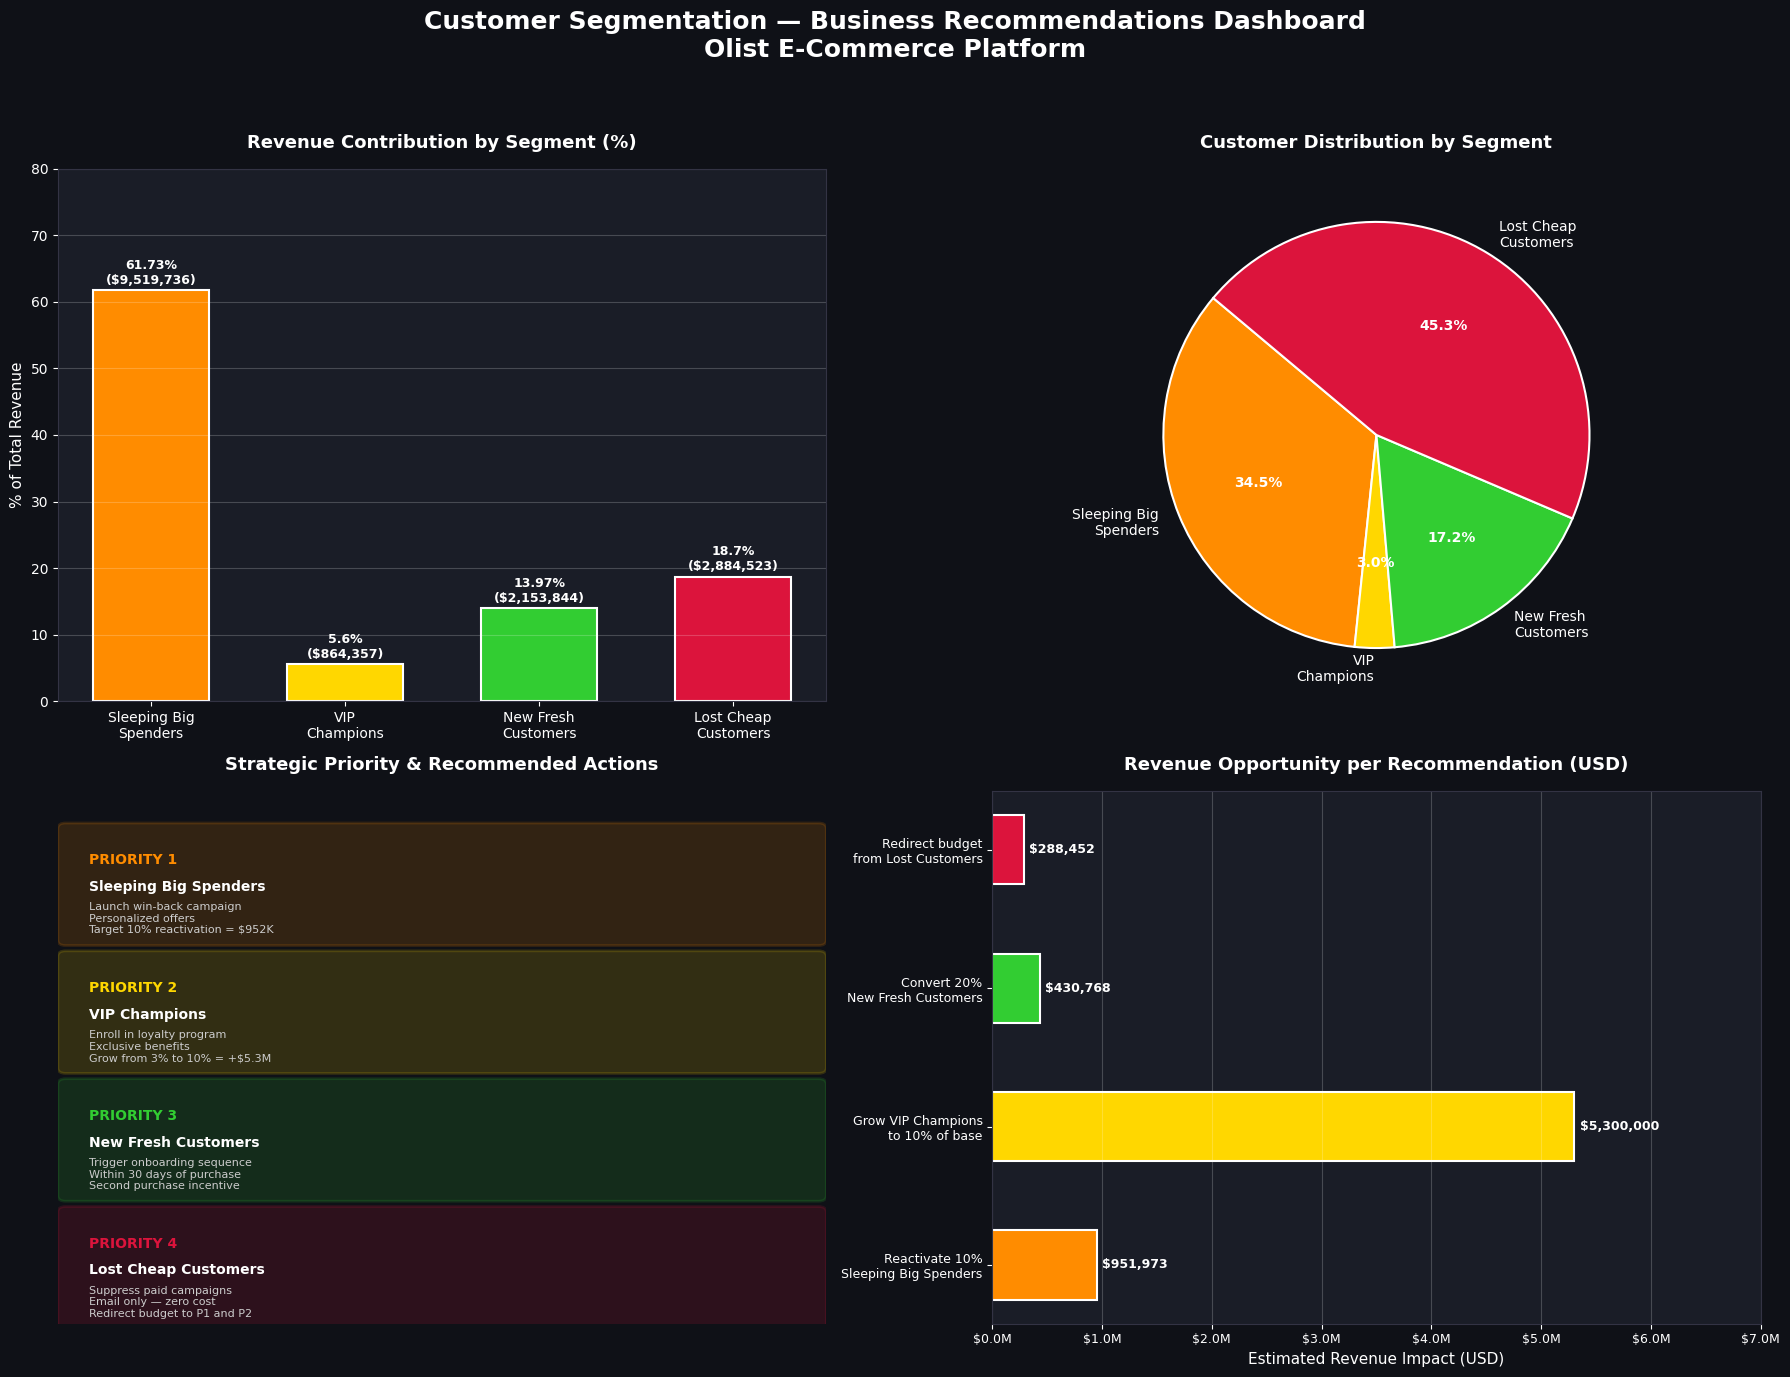

In [ ]:
# ============================================================
# STEP 8: BUSINESS RECOMMENDATIONS DASHBOARD
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.patch.set_facecolor('#0F1117')
fig.suptitle('Customer Segmentation — Business Recommendations Dashboard\nOlist E-Commerce Platform',
             fontsize=18, fontweight='bold', color='white', y=0.98)

# ── COLORS AND DATA ───────────────────────────────────────────
colors = {
    'Sleeping Big Spenders': '#FF8C00',
    'Lost Cheap Customers':  '#DC143C',
    'VIP Champions':         '#FFD700',
    'New Fresh Customers':   '#32CD32'
}

segments   = ['Sleeping Big\nSpenders', 'VIP\nChampions', 'New Fresh\nCustomers', 'Lost Cheap\nCustomers']
customers  = [32185, 2801, 16084, 42287]
revenues   = [9519736, 864357, 2153844, 2884523]
rev_pcts   = [61.73, 5.60, 13.97, 18.70]
priorities = ['PRIORITY 1', 'PRIORITY 2', 'PRIORITY 3', 'PRIORITY 4']
seg_colors = ['#FF8C00', '#FFD700', '#32CD32', '#DC143C']

actions = [
    'Launch win-back campaign\nPersonalized offers\nTarget 10% reactivation = $952K',
    'Enroll in loyalty program\nExclusive benefits\nGrow from 3% to 10% = +$5.3M',
    'Trigger onboarding sequence\nWithin 30 days of purchase\nSecond purchase incentive',
    'Suppress paid campaigns\nEmail only — zero cost\nRedirect budget to P1 and P2'
]

# ── CHART 1: REVENUE CONTRIBUTION ────────────────────────────
ax1 = axes[0, 0]
ax1.set_facecolor('#1A1D27')
bars = ax1.bar(segments, rev_pcts, color=seg_colors,
               edgecolor='white', linewidth=1.5, width=0.6)
ax1.set_title('Revenue Contribution by Segment (%)',
              fontsize=13, fontweight='bold', color='white', pad=15)
ax1.set_ylabel('% of Total Revenue', fontsize=11, color='white')
ax1.tick_params(colors='white', labelsize=10)
ax1.spines[:].set_color('#333344')
for bar, val, rev in zip(bars, rev_pcts, revenues):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val}%\n(${rev:,.0f})',
             ha='center', va='bottom', fontsize=9,
             fontweight='bold', color='white')
ax1.set_ylim(0, 80)
ax1.grid(axis='y', alpha=0.2, color='white')

# ── CHART 2: CUSTOMER COUNT PIE CHART ────────────────────────
ax2 = axes[0, 1]
ax2.set_facecolor('#1A1D27')
wedges, texts, autotexts = ax2.pie(
    customers,
    labels=segments,
    colors=seg_colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    textprops=dict(color='white', fontsize=10)
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax2.set_title('Customer Distribution by Segment',
              fontsize=13, fontweight='bold', color='white', pad=15)

# ── CHART 3: PRIORITY ACTION CARDS ───────────────────────────
ax3 = axes[1, 0]
ax3.set_facecolor('#1A1D27')
ax3.set_xlim(0, 10)
ax3.set_ylim(0, 10)
ax3.axis('off')
ax3.set_title('Strategic Priority & Recommended Actions',
              fontsize=13, fontweight='bold', color='white', pad=15)

card_positions = [7.2, 4.8, 2.4, 0.0]
for i, (priority, segment, action, color) in enumerate(
        zip(priorities, segments, actions, seg_colors)):
    y = card_positions[i]
    rect = FancyBboxPatch((0.1, y), 9.8, 2.1,
                          boxstyle="round,pad=0.1",
                          facecolor=color, alpha=0.15,
                          edgecolor=color, linewidth=2)
    ax3.add_patch(rect)
    ax3.text(0.4, y + 1.5, priority,
             fontsize=10, fontweight='bold', color=color, va='center')
    ax3.text(0.4, y + 1.0, segment.replace('\n', ' '),
             fontsize=10, fontweight='bold', color='white', va='center')
    ax3.text(0.4, y + 0.4, action,
             fontsize=8, color='#CCCCCC', va='center')

# ── CHART 4: REVENUE OPPORTUNITY ─────────────────────────────
ax4 = axes[1, 1]
ax4.set_facecolor('#1A1D27')

opportunities = [
    'Reactivate 10%\nSleeping Big Spenders',
    'Grow VIP Champions\nto 10% of base',
    'Convert 20%\nNew Fresh Customers',
    'Redirect budget\nfrom Lost Customers'
]
opp_values = [951973, 5300000, 430768, 288452]
opp_colors = ['#FF8C00', '#FFD700', '#32CD32', '#DC143C']

bars4 = ax4.barh(opportunities, opp_values,
                 color=opp_colors, edgecolor='white',
                 linewidth=1.5, height=0.5)
ax4.set_title('Revenue Opportunity per Recommendation (USD)',
              fontsize=13, fontweight='bold', color='white', pad=15)
ax4.set_xlabel('Estimated Revenue Impact (USD)', fontsize=11, color='white')
ax4.tick_params(colors='white', labelsize=9)
ax4.spines[:].set_color('#333344')
ax4.grid(axis='x', alpha=0.2, color='white')
for bar, val in zip(bars4, opp_values):
    ax4.text(bar.get_width() + 50000, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}',
             va='center', fontsize=9, fontweight='bold', color='white')
ax4.set_xlim(0, 7000000)
ax4.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('olist_recommendations_dashboard.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0F1117')
plt.show()

# 🎯 Step 8 Output: Business Recommendations Dashboard

## What this dashboard is showing

This dashboard brings together every finding from the entire analysis
into one single actionable view. It is designed to be shown to any
business executive without requiring any data science knowledge.

Four charts work together to tell one complete story.

---

## 📊 Top Left — Revenue Contribution by Segment

This bar chart answers the most important question in the entire project:
where is the money actually coming from?

The orange bar for Sleeping Big Spenders at 61.73% towers over everything else.
This single segment generated $9,519,736 — more than all other three segments
combined. Yet every customer in this group bought exactly once and went silent.

The gold VIP Champions bar is the shortest at 5.6% despite having the highest
average spend. The reason is simple — there are only 2,801 of them.
That gap between per-customer value and total revenue is the single
biggest untapped opportunity on the platform.

---

## 🥧 Top Right — Customer Distribution by Segment

The pie chart shows how the 93,357 customers are divided across segments.

The red slice at 45.3% dominates — nearly half of all customers are
Lost Cheap Customers who contributed the least revenue per head.

The tiny gold slice at 3.0% is the VIP Champions — barely visible on the chart
yet responsible for a disproportionate share of platform value per customer.

Reading both charts together tells the full story:
the biggest slice of customers generates the least revenue per head,
and the smallest slice of customers has the most potential per head.

---

## 📋 Bottom Left — Strategic Priority and Recommended Actions

This panel translates the data into four clear business actions
ranked by revenue priority and color coded by segment.

Priority 1 — Sleeping Big Spenders (orange)
The most urgent action on the entire platform.
61.7% of revenue is sitting dormant. A win-back campaign
targeting just 10% reactivation recovers nearly $1 million.

Priority 2 — VIP Champions (gold)
The highest long term investment opportunity.
Growing this segment from 3% to 10% of the base adds $5.3 million.
Every resource put into loyalty and retention here compounds over time.

Priority 3 — New Fresh Customers (green)
The highest urgency action based on timing.
These customers are still warm but cooling fast.
A 30 day onboarding sequence is the difference between
keeping them or losing them to the inactive segments forever.

Priority 4 — Lost Cheap Customers (red)
The lowest priority on the platform.
Suppress from paid campaigns entirely.
Every dollar saved here gets redirected to Priorities 1 through 3.

---

## 💰 Bottom Right — Revenue Opportunity per Recommendation

This horizontal bar chart puts a dollar figure on every recommended action.

Growing VIP Champions to 10% of the base is the single largest
opportunity at an estimated $5,300,000 — the longest bar on the chart.

Reactivating 10% of Sleeping Big Spenders comes in second at $951,973 —
nearly $1 million from one focused campaign.

Converting 20% of New Fresh Customers adds $430,768.

Redirecting budget from Lost Cheap Customers frees up $288,452
to reinvest into the higher priority segments.

Combined total revenue opportunity across all four recommendations:
$6,971,193 — representing a 45% increase on current platform revenue.

---

## 🎯 The Final Business Case

This analysis started with a simple question:
who are Olist's customers and what should the business do about them?

The answer is now clear, visual, and backed by $15.4 million in real transaction data:

> Olist does not need more customers.
> It needs to keep the ones it already has.

The four strategies in this dashboard — executed together —
represent a $6.97 million revenue opportunity sitting untouched
inside a customer base Olist already paid to acquire.

That is the business case. That is the deliverable.
That is what this project set out to find.

# 💾 Exporting the Final Results

## What is this step doing?

Every step so far has been analysis — loading, cleaning, modeling, and visualizing.

This final step exports the work into a deliverable that a real client can use.

In a real consulting engagement the last thing you hand to the client
is not a chart or a notebook — it is a clean, labeled dataset they can
plug directly into their CRM, email marketing platform, or sales system
and start acting on immediately.

---

## What will we export?

A single CSV file containing every one of the 93,357 customers with:

- Their unique customer ID
- Their Recency, Frequency, and Monetary scores
- Their cluster number
- Their segment label in plain English
- Their priority level
- Their recommended action

This file is the bridge between data science and business execution.
A marketing team can open this in Excel, filter by segment,
and launch a campaign the same day.

That is the real world value of everything we built.

In [ ]:
# ============================================================
# EXPORT FINAL SEGMENTED CUSTOMER TABLE
# ============================================================

import pandas as pd

# ── ADD PRIORITY AND ACTION COLUMNS ──────────────────────────
# Map each cluster to a priority level and recommended action

priority_map = {
    0: 'Priority 1 — Reactivate',
    1: 'Priority 4 — Deprioritize',
    2: 'Priority 2 — Protect and Grow',
    3: 'Priority 3 — Convert Now'
}

action_map = {
    0: 'Launch win-back campaign with personalized offer tied to original purchase category',
    1: 'Suppress from paid campaigns. Email only with single low-cost incentive.',
    2: 'Enroll in loyalty program. Exclusive benefits. Personal outreach every 60 days.',
    3: 'Trigger onboarding sequence within 30 days. Second purchase incentive.'
}

rfm['Priority']           = rfm['Cluster'].map(priority_map)
rfm['Recommended_Action'] = rfm['Cluster'].map(action_map)

# ── BUILD THE FINAL EXPORT TABLE ─────────────────────────────
export_df = rfm[[
    'customer_unique_id',
    'Recency',
    'Frequency',
    'Monetary',
    'Cluster',
    'Cluster_Label',
    'Priority',
    'Recommended_Action'
]].copy()

# Rename columns for clarity
export_df.columns = [
    'Customer_ID',
    'Recency_Days',
    'Frequency_Orders',
    'Monetary_USD',
    'Cluster_Number',
    'Segment',
    'Priority',
    'Recommended_Action'
]

# ── EXPORT TO CSV ─────────────────────────────────────────────
export_df.to_csv('olist_customer_segments.csv', index=False)

# ── PREVIEW THE EXPORT ────────────────────────────────────────
print("✅ Export complete")
print(f"\n📁 File saved as: olist_customer_segments.csv")
print(f"📐 Total rows exported: {len(export_df):,}")
print(f"\n👀 Preview — first 10 rows:")
print(export_df.head(10).to_string())
print(f"\n📊 Segment breakdown in exported file:")
print(export_df['Segment'].value_counts())

✅ Export complete

📁 File saved as: olist_customer_segments.csv
📐 Total rows exported: 93,357

👀 Preview — first 10 rows:
                        Customer_ID  Recency_Days  Frequency_Orders  Monetary_USD  Cluster_Number                Segment                   Priority                                                                   Recommended_Action
0  0000366f3b9a7992bf8c76cfdf3221e2           112                 1        141.90               0  Sleeping Big Spenders    Priority 1 — Reactivate  Launch win-back campaign with personalized offer tied to original purchase category
1  0000b849f77a49e4a4ce2b2a4ca5be3f           115                 1         27.19               1   Lost Cheap Customers  Priority 4 — Deprioritize             Suppress from paid campaigns. Email only with single low-cost incentive.
2  0000f46a3911fa3c0805444483337064           537                 1         86.22               1   Lost Cheap Customers  Priority 4 — Deprioritize             Suppress from paid 

# 💾 Output: Final Export Complete

## What was just created

A single CSV file — olist_customer_segments.csv — containing all 93,357
customers, each fully labeled with their segment, priority, and recommended action.

This file is the final deliverable of the entire project.

---

## Reading the Export Preview

Each row in the exported file represents one unique customer.
The 8 columns tell a complete story about every customer:

| Column | What it contains |
|---|---|
| Customer_ID | Unique anonymized customer identifier |
| Recency_Days | Days since their last purchase |
| Frequency_Orders | Total number of orders placed |
| Monetary_USD | Total amount spent in USD |
| Cluster_Number | The K-means cluster assigned (0, 1, 2, or 3) |
| Segment | Plain English segment label |
| Priority | Business priority level for this customer |
| Recommended_Action | Exact action the marketing team should take |

---

## What a marketing team does with this file

Step 1 — Open the file in Excel or upload directly to a CRM like Salesforce
Step 2 — Filter by Priority 1 to get all 32,185 Sleeping Big Spenders
Step 3 — Export that list to the email marketing platform
Step 4 — Launch the win-back campaign with personalized offers
Step 5 — Repeat for each priority segment with its specific action

The entire process from data science output to marketing execution
takes less than one business day. That is the value of a clean deliverable.

---

## Final Segment Breakdown in the Exported File

| Segment | Customers Exported |
|---|---|
| 🔴 Lost Cheap Customers | 42,287 |
| 🟠 Sleeping Big Spenders | 32,185 |
| 🟢 New Fresh Customers | 16,084 |
| 🌟 VIP Champions | 2,801 |
| Total | 93,357 |

Every single customer has been accounted for.
No customer is left unlabeled or unactionable.

---

## Why this matters in a real business context

Most data science projects end with a chart or a model.
This project ends with something a business can actually use tomorrow.

The CSV file bridges the gap between analysis and execution.
It takes the output of a K-means clustering algorithm —
a concept that most business stakeholders will never understand —
and translates it into a simple spreadsheet with clear instructions.

That translation from technical output to business action
is the most valuable skill in any data science or consulting role.

> A model that never gets used is worthless.
> A deliverable that drives action is everything.